# 5.2 无监督学习 (Unsupervised Learning)

> **课时**: 约2课时 | **难度**: ⭐⭐⭐ | **标签**: `无监督学习` `聚类` `降维` `PCA`

---

## 📚 本节目标

- 理解无监督学习的核心思想：从无标签数据中发现隐藏结构
- 掌握 K-Means 聚类算法原理（Lloyd 算法）
- 了解层次聚类的基本概念
- 掌握 PCA 降维的数学原理（特征值分解）
- 了解 t-SNE 的基本思想
- 使用 Scikit-learn 进行聚类分析和 PCA 降维可视化


## 一、无监督学习概述

### 1.1 定义

无监督学习处理的是**没有标签的数据**，目标是发现数据中内在的结构和模式。

与监督学习的对比：

```
监督学习:   X (特征) + y (标签)  →  学习 f(x) ≈ y
无监督学习: X (特征)            →  发现 X 的隐藏结构
```

### 1.2 主要任务类型

| 任务 | 目标 | 典型算法 | 应用场景 |
|------|------|----------|----------|
| **聚类 (Clustering)** | 将数据分为若干组，组内相似，组间差异大 | K-Means, 层次聚类, DBSCAN | 客户分群、图像分割 |
| **降维 (Dimensionality Reduction)** | 将高维数据映射到低维空间 | PCA, t-SNE, UMAP | 数据可视化、特征压缩 |
| **关联规则** | 发现变量之间的关联关系 | Apriori, FP-Growth | 购物篮分析 |
| **密度估计** | 估计数据的概率分布 | GMM, KDE | 异常检测 |

本节重点讲解**聚类**和**降维**两大任务。

## 二、聚类 — K-Means 算法

### 2.1 K-Means 目标

给定 $N$ 个数据点，将它们分成 $K$ 个簇（cluster），使得簇内平方和（Within-Cluster Sum of Squares, WCSS）最小化：

$$\min_{C_1, \ldots, C_K} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

其中 $\mu_k$ 是第 $k$ 个簇的质心（centroid）：

$$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$

### 2.2 Lloyd 算法（迭代求解）

K-Means 使用 Lloyd 迭代算法来近似求解这个优化问题：

```
算法: K-Means (Lloyd算法)
输入: 数据集 X = {x₁, x₂, ..., xₙ}, 簇数 K
输出: K 个簇的分配

1. 随机初始化 K 个质心 μ₁, μ₂, ..., μₖ
2. repeat:
     a. 分配步: 将每个点分配到最近的质心
        c_i = argmin_k ||x_i - μ_k||²
     b. 更新步: 重新计算每个簇的质心
        μ_k = mean(x_i), x_i ∈ C_k
3. until 质心不再变化 (或变化小于阈值)
```

**关键特点**:
- 时间复杂度: $O(n \cdot K \cdot I \cdot d)$，其中 $I$ 是迭代次数，$d$ 是维度
- 结果依赖于初始化，通常多次运行取最优
- 收敛到**局部最优**，不保证全局最优

### 2.3 从零实现 K-Means

让我们用 NumPy 从零实现 K-Means 算法：

In [1]:
# ============================================
# 从零实现 K-Means 算法
# ============================================
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class KMeansScratch:
    """从零实现的K-Means聚类算法"""
    
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None
    
    def _init_centroids(self, X):
        """随机初始化质心"""
        idx = np.random.choice(X.shape[0], self.k, replace=False)
        return X[idx].copy()
    
    def _assign_clusters(self, X):
        """分配步：将每个点分配到最近的质心"""
        distances = np.zeros((X.shape[0], self.k))
        for k in range(self.k):
            distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X):
        """更新步：重新计算质心"""
        new_centroids = np.zeros_like(self.centroids)
        for k in range(self.k):
            mask = self.labels == k
            if np.sum(mask) > 0:
                new_centroids[k] = X[mask].mean(axis=0)
            else:
                new_centroids[k] = self.centroids[k]
        return new_centroids
    
    def fit(self, X):
        """训练 K-Means"""
        self.centroids = self._init_centroids(X)
        
        for i in range(self.max_iters):
            # 分配步
            self.labels = self._assign_clusters(X)
            # 更新步
            new_centroids = self._update_centroids(X)
            # 检查收敛
            shift = np.sqrt(np.sum((new_centroids - self.centroids)**2))
            self.centroids = new_centroids
            
            if shift < self.tol:
                print(f"K-Means 在第 {i+1} 轮收敛")
                break
        else:
            print(f"K-Means 达到最大迭代次数 {self.max_iters}")
        
        return self
    
    def inertia(self, X):
        """计算 WCSS (簇内平方和)"""
        total = 0
        for k in range(self.k):
            mask = self.labels == k
            total += np.sum((X[mask] - self.centroids[k])**2)
        return total

print("K-Means 类定义完成！")

K-Means 类定义完成！


In [2]:
# 生成测试数据并测试我们的 K-Means
from sklearn.datasets import make_blobs

# 生成 3 个簇的模拟数据
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.5,
                              random_state=42, center_box=(-8, 8))

# 运行我们的 K-Means
kmeans_custom = KMeansScratch(k=3, max_iters=100)
kmeans_custom.fit(X_blobs)

print(f"WCSS (簇内平方和): {kmeans_custom.inertia(X_blobs):.2f}")
print(f"质心坐标:\n{kmeans_custom.centroids.round(2)}")
print(f"簇大小: {[np.sum(kmeans_custom.labels == i) for i in range(3)]}")

K-Means 在第 4 轮收敛
WCSS (簇内平方和): 1275.43
质心坐标:
[[-2.19  7.26]
 [-5.51 -5.66]
 [ 3.87  1.63]]
簇大小: [100, 100, 100]


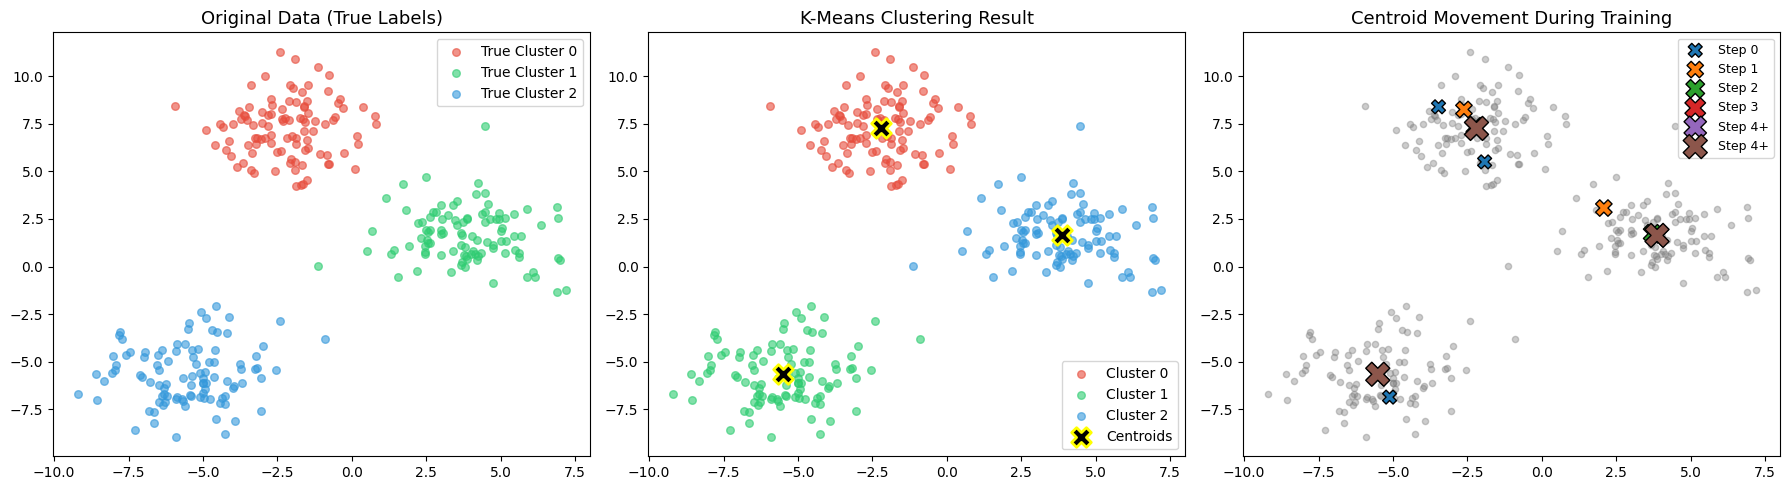

In [3]:
# 可视化 K-Means 聚类结果
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_k = ['#e74c3c', '#2ecc71', '#3498db']

# 左图：原始数据（带真实标签）
for i in range(3):
    mask = y_blobs == i
    axes[0].scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                    c=colors_k[i], label=f'True Cluster {i}', alpha=0.6, s=30)
axes[0].set_title('Original Data (True Labels)', fontsize=13)
axes[0].legend(fontsize=10)

# 中图：K-Means 聚类结果
for i in range(3):
    mask = kmeans_custom.labels == i
    axes[1].scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                    c=colors_k[i], label=f'Cluster {i}', alpha=0.6, s=30)
# 绘制质心
axes[1].scatter(kmeans_custom.centroids[:, 0], kmeans_custom.centroids[:, 1],
                marker='X', s=200, c='black', edgecolors='yellow', linewidths=2,
                zorder=5, label='Centroids')
axes[1].set_title('K-Means Clustering Result', fontsize=13)
axes[1].legend(fontsize=10)

# 右图：迭代过程可视化
# 重新运行并记录每次迭代的质心
kmeans_viz = KMeansScratch(k=3, max_iters=10)
kmeans_viz.centroids = kmeans_viz._init_centroids(X_blobs)
centroids_history = [kmeans_viz.centroids.copy()]

for iteration in range(5):
    kmeans_viz.labels = kmeans_viz._assign_clusters(X_blobs)
    kmeans_viz.centroids = kmeans_viz._update_centroids(X_blobs)
    centroids_history.append(kmeans_viz.centroids.copy())

# 绘制数据点
axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c='gray', alpha=0.4, s=20)
for step, cents in enumerate(centroids_history):
    axes[2].scatter(cents[:, 0], cents[:, 1], marker='X', s=100 + step*40,
                    c=[f'C{step}'] * 3, edgecolors='black', linewidths=1,
                    label=f'Step {step}' if step < 4 else 'Step 4+')
axes[2].set_title('Centroid Movement During Training', fontsize=13)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 三、肘部法则（Elbow Method）选择 K 值

K-Means 需要预先指定簇数 $K$，但如何选择最优的 $K$？

**肘部法则**的核心思想：随着 $K$ 增大，WCSS 会单调递减。当 $K$ 从小增大时，WCSS 下降速度最快的拐点（"肘部"）就是较优的 $K$ 值。

$$WCSS(K) = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

```
WCSS
  |\
  | \\        ← 肘部 (Elbow): 下降速度骤减
  |  \\─────
  |   \\n
  |    \\_________
  |________________\ K
      K*      
```

In [4]:
# 肘部法则示例
from sklearn.cluster import KMeans

wcss_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_blobs)
    wcss_values.append(km.inertia_)
    print(f"K={k:2d}: WCSS = {km.inertia_:.2f}")

# 计算下降率
print("\n下降率分析:")
for i in range(1, len(wcss_values)):
    drop = wcss_values[i-1] - wcss_values[i]
    pct = drop / wcss_values[i-1] * 100
    print(f"  K={i} → K={i+1}: 下降 {drop:.2f} ({pct:.1f}%)")

K= 1: WCSS = 14190.17
K= 2: WCSS = 4694.95
K= 3: WCSS = 1275.43
K= 4: WCSS = 1118.23
K= 5: WCSS = 959.27
K= 6: WCSS = 811.22
K= 7: WCSS = 718.07
K= 8: WCSS = 613.16
K= 9: WCSS = 546.75
K=10: WCSS = 490.73

下降率分析:
  K=1 → K=2: 下降 9495.23 (66.9%)
  K=2 → K=3: 下降 3419.51 (72.8%)
  K=3 → K=4: 下降 157.20 (12.3%)
  K=4 → K=5: 下降 158.96 (14.2%)
  K=5 → K=6: 下降 148.05 (15.4%)
  K=6 → K=7: 下降 93.15 (11.5%)
  K=7 → K=8: 下降 104.91 (14.6%)
  K=8 → K=9: 下降 66.41 (10.8%)
  K=9 → K=10: 下降 56.02 (10.2%)


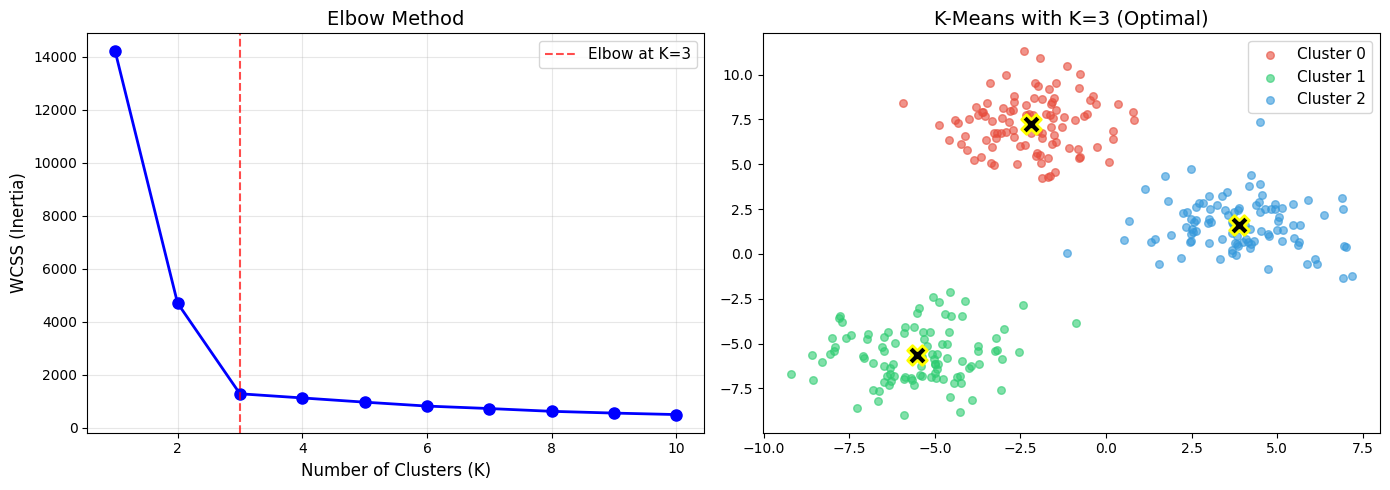

In [5]:
# 可视化肘部法则
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：WCSS 曲线
axes[0].plot(list(K_range), wcss_values, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='r', linestyle='--', alpha=0.7, label='Elbow at K=3')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：K=3时的聚类结果
km3 = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_3 = km3.fit_predict(X_blobs)
for i in range(3):
    mask = labels_3 == i
    axes[1].scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                    c=colors_k[i], label=f'Cluster {i}', alpha=0.6, s=30)
axes[1].scatter(km3.cluster_centers_[:, 0], km3.cluster_centers_[:, 1],
                marker='X', s=200, c='black', edgecolors='yellow', linewidths=2, zorder=5)
axes[1].set_title('K-Means with K=3 (Optimal)', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

## 四、层次聚类 (Hierarchical Clustering)

### 4.1 基本思想

层次聚类不需要预先指定簇数 $K$，而是构建一棵**聚类树（树状图 / Dendrogram）**。

### 4.2 凝聚式层次聚类（自底向上）

```
1. 每个数据点初始化为一个簇
2. 计算所有簇对之间的距离
3. 合并距离最近的两个簇
4. 重复步骤 2-3，直到所有点合并为一个簇
5. 通过设置距离阈值，在树状图的合适位置"切割"得到最终簇数
```

**常用距离度量**（簇间距离）：

| 方法 | 描述 |
|------|------|
| Single Linkage | 两个簇中最近两点间的距离 |
| Complete Linkage | 两个簇中最远两点间的距离 |
| Average Linkage | 两个簇中所有点对距离的均值 |
| Ward's Method | 合并后 WCSS 增量最小 |

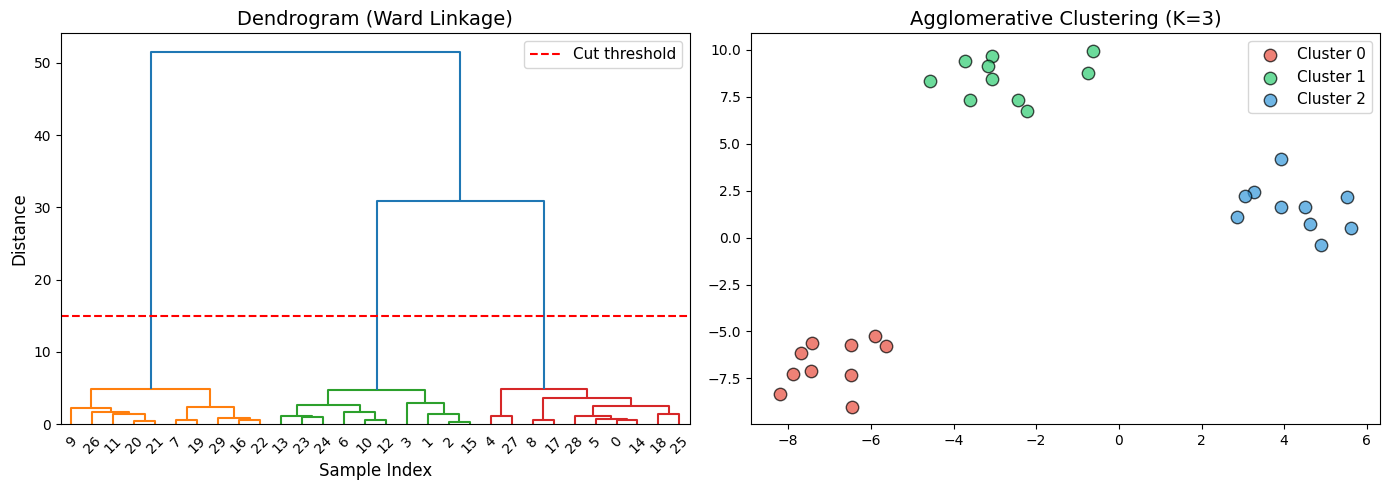

In [6]:
# 层次聚类示例
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 使用较小的数据集来展示树状图
X_small, y_small = make_blobs(n_samples=30, centers=3, cluster_std=1.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：树状图 (Dendrogram)
Z = linkage(X_small, method='ward')
dendrogram(Z, ax=axes[0], color_threshold=15)
axes[0].axhline(y=15, color='r', linestyle='--', label='Cut threshold')
axes[0].set_title('Dendrogram (Ward Linkage)', fontsize=14)
axes[0].set_xlabel('Sample Index', fontsize=12)
axes[0].set_ylabel('Distance', fontsize=12)
axes[0].legend(fontsize=11)

# 右图：聚类结果
agg_clust = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg_clust.fit_predict(X_small)
for i in range(3):
    mask = labels_agg == i
    axes[1].scatter(X_small[mask, 0], X_small[mask, 1],
                    c=colors_k[i], label=f'Cluster {i}', s=80, alpha=0.7, edgecolors='k')
axes[1].set_title('Agglomerative Clustering (K=3)', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## 五、降维 — PCA 主成分分析

### 5.1 为什么需要降维？

- **维度灾难**: 特征越多，需要的数据量指数增长
- **可视化**: 人眼只能理解 2D/3D 空间
- **去噪**: 保留主要信息，去除噪声
- **加速**: 减少计算量

### 5.2 PCA 原理（特征值分解）

PCA 通过**特征值分解**找到数据方差最大的方向（主成分）。

**步骤**:

1. **标准化**: 将数据零均值化（$X_{centered} = X - \bar{X}$）

2. **计算协方差矩阵**:

$$\Sigma = \frac{1}{N-1} X_{centered}^T \cdot X_{centered}$$

3. **特征值分解**:

$$\Sigma = V \Lambda V^T$$

其中 $V$ 是特征向量矩阵（主成分方向），$\Lambda$ 是特征值对角矩阵（对应方差大小）。

4. **选择前 $d$ 个主成分**: 选择特征值最大的 $d$ 个特征向量

5. **投影**: $X_{reduced} = X_{centered} \cdot V_d$

**方差解释比**（第 $i$ 个主成分）:

$$\text{Variance Ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{D} \lambda_j}$$

In [7]:
# ============================================
# 从零实现 PCA
# ============================================
import numpy as np

def pca_from_scratch(X, n_components=2):
    """从零实现PCA"""
    # Step 1: 标准化 (零均值)
    X_centered = X - np.mean(X, axis=0)
    
    # Step 2: 计算协方差矩阵
    cov_matrix = (X_centered.T @ X_centered) / (X.shape[0] - 1)
    
    # Step 3: 特征值分解
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Step 4: 按特征值降序排序
    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]
    
    # Step 5: 选择前 n_components 个主成分
    W = eigenvectors[:, :n_components]
    
    # Step 6: 投影
    X_reduced = X_centered @ W
    
    # 方差解释比
    var_ratio = eigenvalues[:n_components] / eigenvalues.sum()
    
    return X_reduced, var_ratio, eigenvalues

# 测试：使用鸢尾花数据集
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data

print(f"原始维度: {X_iris.shape[1]}")
X_pca, var_ratio, eigenvalues = pca_from_scratch(X_iris, n_components=2)
print(f"降维后维度: {X_pca.shape[1]}")
print(f"\n各特征值: {eigenvalues.round(4)}")
print(f"方差解释比: PC1={var_ratio[0]*100:.1f}%, PC2={var_ratio[1]*100:.1f}%")
print(f"累计方差解释比: {sum(var_ratio)*100:.1f}%")

原始维度: 4
降维后维度: 2

各特征值: [4.2282 0.2427 0.0782 0.0238]
方差解释比: PC1=92.5%, PC2=5.3%
累计方差解释比: 97.8%


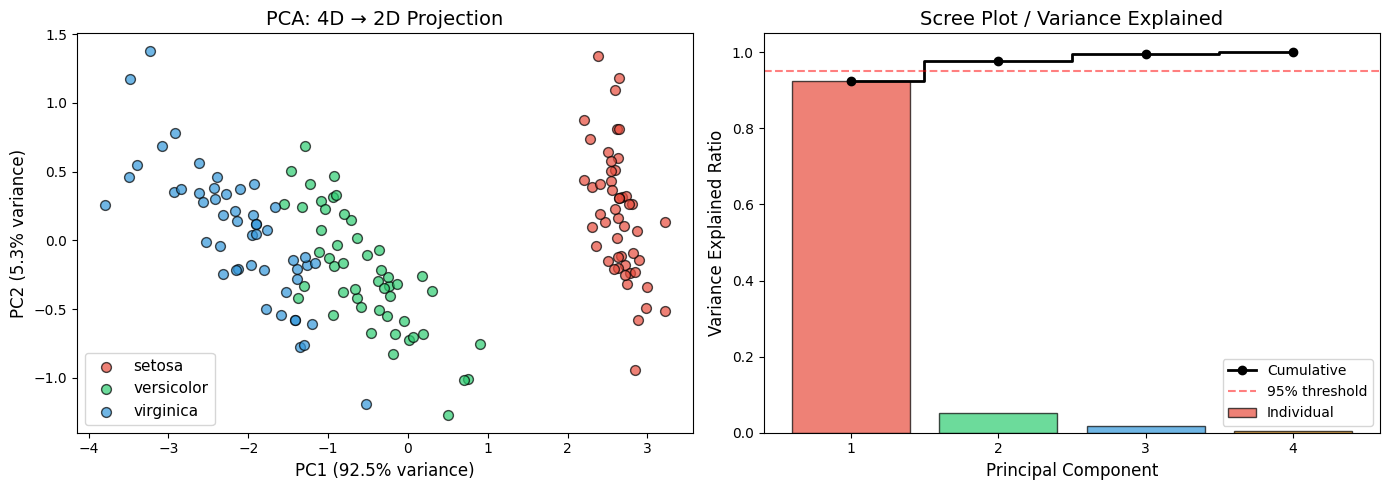

In [8]:
# 可视化 PCA 降维结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：PCA 降维后的 2D 散点图
colors_pca = ['#e74c3c', '#2ecc71', '#3498db']
for i, target_name in enumerate(iris.target_names):
    mask = iris.target == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_pca[i], label=target_name, alpha=0.7, s=50, edgecolors='k')

axes[0].set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}% variance)', fontsize=12)
axes[0].set_title('PCA: 4D → 2D Projection', fontsize=14)
axes[0].legend(fontsize=11)

# 右图：累积方差解释比
cumulative_var = np.cumsum(eigenvalues / eigenvalues.sum())
axes[1].bar(range(1, 5), eigenvalues / eigenvalues.sum(), alpha=0.7,
           color=['#e74c3c', '#2ecc71', '#3498db', '#f39c12'], edgecolor='black', label='Individual')
axes[1].step(range(1, 5), cumulative_var, where='mid', color='black',
            linewidth=2, marker='o', label='Cumulative')
axes[1].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% threshold')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Variance Explained Ratio', fontsize=12)
axes[1].set_title('Scree Plot / Variance Explained', fontsize=14)
axes[1].set_xticks([1, 2, 3, 4])
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('pca_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 六、t-SNE 概述

### 6.1 t-SNE 与 PCA 的区别

| | PCA | t-SNE |
|---|---|---|
| 类型 | 线性降维 | 非线性降维 |
| 目标 | 最大化方差保留 | 保留局部邻域结构 |
| 距离保持 | 全局结构 | 局部结构 |
| 计算复杂度 | $O(d^2 \cdot n)$ | $O(n^2)$（更高） |
| 适用场景 | 特征压缩、预处理 | 高维数据可视化 |

### 6.2 t-SNE 核心思想

t-SNE 通过两个步骤：

1. **高维空间**: 用高斯分布衡量点对之间的相似度
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

2. **低维空间**: 用 t 分布（自由度为1）衡量点对之间的相似度
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$$

3. **优化目标**: 最小化两个分布之间的 KL 散度
$$\min \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**⚠️ 注意**: t-SNE 主要用于**可视化**，不直接用于下游任务的特征输入。

In [9]:
# t-SNE 可视化示例
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 使用_digits数据集（64维 → 2维）
from sklearn.datasets import load_digits
digits = load_digits()
X_digits = digits.data  # (1797, 64)
y_digits = digits.target  # 0-9

# 标准化
X_digits_scaled = StandardScaler().fit_transform(X_digits)

print(f"原始维度: {X_digits_scaled.shape}")

# PCA 降维
from sklearn.decomposition import PCA
X_pca_digits = PCA(n_components=2).fit_transform(X_digits_scaled)

# t-SNE 降维（可能需要较长时间）
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_digits = tsne.fit_transform(X_digits_scaled)

print(f"PCA 降维后: {X_pca_digits.shape}")
print(f"t-SNE 降维后: {X_tsne_digits.shape}")

原始维度: (1797, 64)
PCA 降维后: (1797, 2)
t-SNE 降维后: (1797, 2)


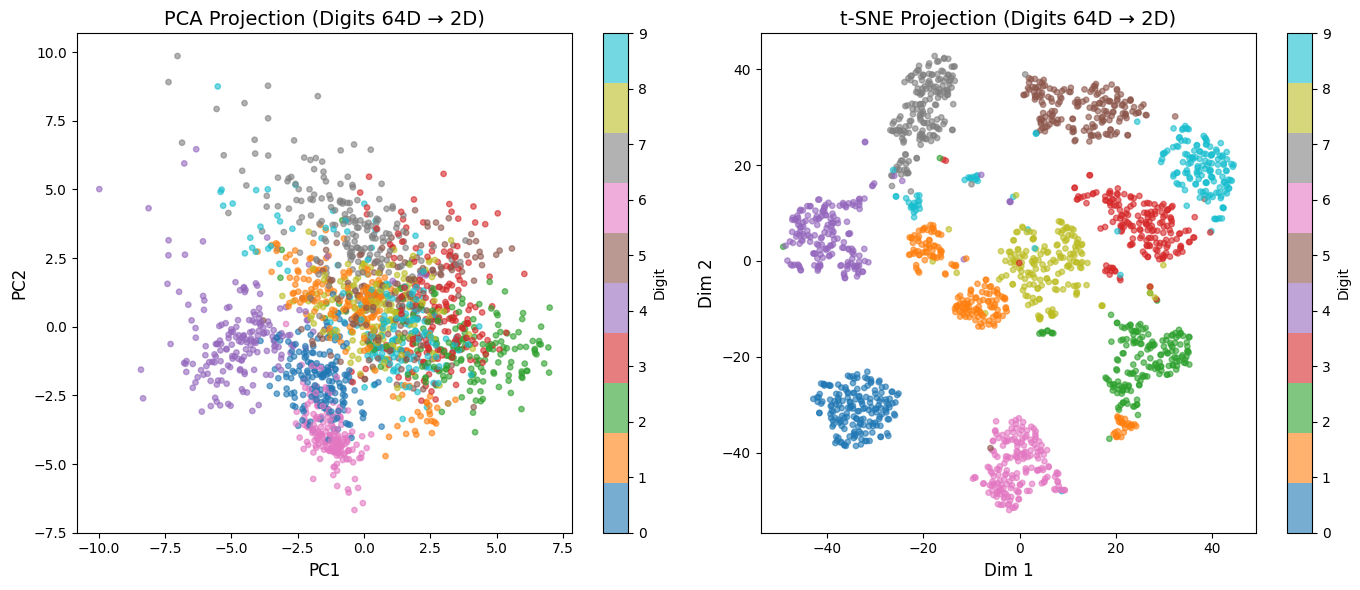

观察：t-SNE 能更好地分离不同的数字类别簇！


In [10]:
# 对比 PCA 和 t-SNE 的可视化效果
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
scatter1 = axes[0].scatter(X_pca_digits[:, 0], X_pca_digits[:, 1],
                            c=y_digits, cmap='tab10', s=15, alpha=0.6)
axes[0].set_title('PCA Projection (Digits 64D → 2D)', fontsize=14)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
fig.colorbar(scatter1, ax=axes[0], label='Digit')

# t-SNE
scatter2 = axes[1].scatter(X_tsne_digits[:, 0], X_tsne_digits[:, 1],
                            c=y_digits, cmap='tab10', s=15, alpha=0.6)
axes[1].set_title('t-SNE Projection (Digits 64D → 2D)', fontsize=14)
axes[1].set_xlabel('Dim 1', fontsize=12)
axes[1].set_ylabel('Dim 2', fontsize=12)
fig.colorbar(scatter2, ax=axes[1], label='Digit')

plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("观察：t-SNE 能更好地分离不同的数字类别簇！")

## 🏋️ 练习题

### 练习1：概念理解

**Q1**: K-Means 和层次聚类的主要区别是什么？各有什么优缺点？

**Q2**: 为什么 PCA 要选择方差最大的方向作为主成分？如果选择方差最小的方向会怎样？

**Q3**: 为什么 t-SNE 不适合直接用于机器学习流水线中的特征降维？

### 练习2：代码实践

**Q4**: 对鸢尾花数据集，使用 K-Means 进行聚类（K=3），并绘制聚类结果与真实标签的对比图。计算聚类结果的 Adjusted Rand Index (ARI)。

**Q5**: 使用 PCA 将鸢尾花数据降维到 2 维，然后对降维后的数据使用 K-Means 聚类。比较降维前后聚类的效果。


Adjusted Rand Index (ARI): 0.6201
(ARI 范围: [-1, 1], 1 表示完全一致)


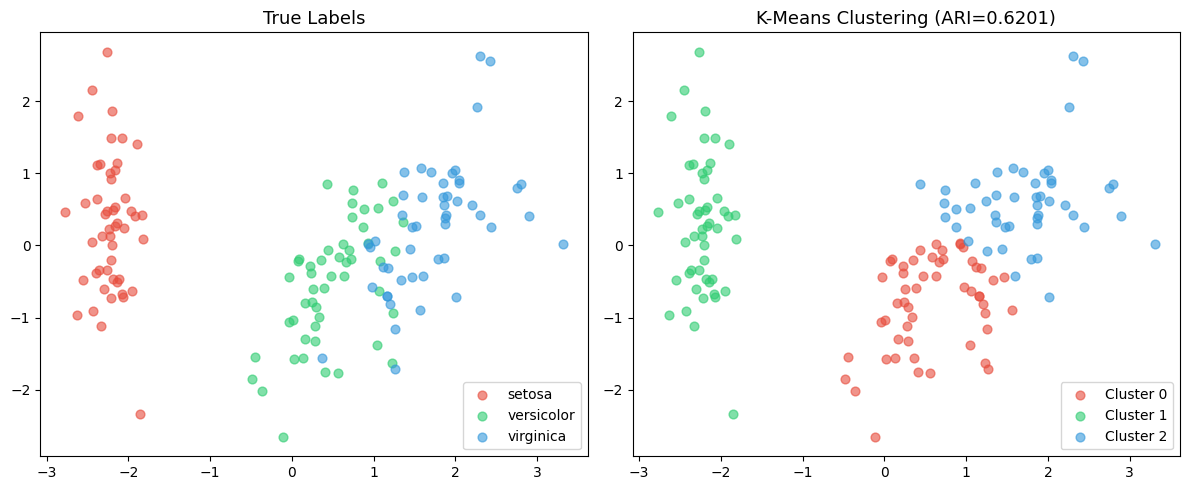

In [11]:
# 练习4: 参考答案
from sklearn.metrics import adjusted_rand_score

# 对鸢尾花数据进行 K-Means 聚类
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

km_iris = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_pred = km_iris.fit_predict(X_iris)

# ARI 评分 (聚类与真实标签的吻合度)
ari = adjusted_rand_score(iris.target, labels_pred)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"(ARI 范围: [-1, 1], 1 表示完全一致)")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 使用 PCA 投影到 2D 来可视化
from sklearn.decomposition import PCA
X_2d = PCA(n_components=2).fit_transform(X_iris)
colors_q = ['#e74c3c', '#2ecc71', '#3498db']

# 真实标签
for i, name in enumerate(iris.target_names):
    mask = iris.target == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors_q[i], label=name, alpha=0.6, s=40)
axes[0].set_title('True Labels', fontsize=13)
axes[0].legend(fontsize=10)

# 聚类标签
for i in range(3):
    mask = labels_pred == i
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors_q[i], label=f'Cluster {i}', alpha=0.6, s=40)
axes[1].set_title(f'K-Means Clustering (ARI={ari:.4f})', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('exercise_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# 练习5: 参考答案 - PCA 降维后聚类

# 方法1：原始数据聚类
km_raw = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_raw = km_raw.fit_predict(X_iris)
ari_raw = adjusted_rand_score(iris.target, labels_raw)

# 方法2：PCA 降维后聚类
X_pca_3d = PCA(n_components=2).fit_transform(X_iris)
km_pca = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_pca = km_pca.fit_predict(X_pca_3d)
ari_pca = adjusted_rand_score(iris.target, labels_pca)

print(f"原始数据聚类 ARI: {ari_raw:.4f}")
print(f"PCA降维后聚类 ARI: {ari_pca:.4f}")
print(f"\n结论: 鸢尾花数据只有4个特征，PCA降维可能会丢失一些信息，")
print(f"但对于高维数据（如100+维），PCA降维后聚类往往效果更好（去除噪声维度）。")

原始数据聚类 ARI: 0.6201
PCA降维后聚类 ARI: 0.6201

结论: 鸢尾花数据只有4个特征，PCA降维可能会丢失一些信息，
但对于高维数据（如100+维），PCA降维后聚类往往效果更好（去除噪声维度）。


---

## 📌 本节小结

| 知识点 | 要点 |
|--------|------|
| K-Means | 迭代分配+更新质心，最小化 WCSS |
| 肘部法则 | WCSS 下降拐点处选择最优 K |
| 层次聚类 | 构建树状图，无需预设 K，支持不同粒度 |
| PCA | 特征值分解 → 找最大方差方向 → 投影降维 |
| t-SNE | 非线性降维，适合高维可视化 |

**下一节**: [5.3 强化学习](./5.3_强化学习.ipynb)